## setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("./data/all/extracted_data.csv")
df

,name,thoracic_width,cardiac_width,ctr,gender
0,jsrt-JPCLN001,389.0,184.0,0.473,NaN
1,jsrt-JPCLN002,362.0,222.0,0.613,NaN
2,jsrt-JPCLN003,371.0,184.0,0.496,NaN
3,jsrt-JPCLN004,377.0,172.0,0.456,NaN
4,jsrt-JPCLN005,373.0,234.0,0.627,NaN
...,...,...,...,...,...
1082,shenzhen-M-1557,335.0,NaN,NaN,M
1083,shenzhen-M-1559,349.0,NaN,NaN,M
1084,shenzhen-M-1561,428.0,NaN,NaN,M
1085,shenzhen-M-1564,336.0,NaN,NaN,M


## ctr distrobution

In [3]:
def plot_ctr_histogram(df, range_step, show_normal_range=True):
    step = range_step
    ctr_min = df['ctr'].min()
    ctr_max = df['ctr'].max()
    
    start = 0.50 + step * np.floor((ctr_min - 0.50) / step)
    stop = 0.50 + step * np.ceil((ctr_max - 0.50) / step)  # Removed: + step
    bin_edges = np.arange(start, stop, step)
    
    sns.set_style("whitegrid")
    plt.figure(figsize=(10, 6))
    sns.histplot(df['ctr'].dropna(), bins=bin_edges, color='orange')

    if show_normal_range:
        plt.axvline(x=0.42, color='blue', linestyle='--', label='Normal Aralık')
        plt.axvline(x=0.50, color='blue', linestyle='--')

    plt.xticks(bin_edges)
    plt.title('KTO Dağılımı')
    plt.xlabel('KTO')
    plt.ylabel('Sayı')
    if show_normal_range:
        plt.legend()
    plt.show()

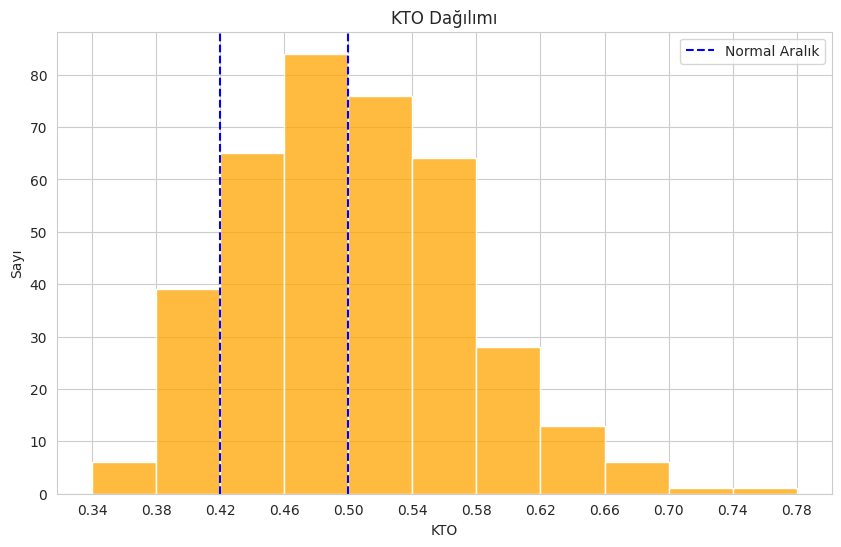

In [4]:
plot_ctr_histogram(df, 0.04, show_normal_range=True)

## gender counts

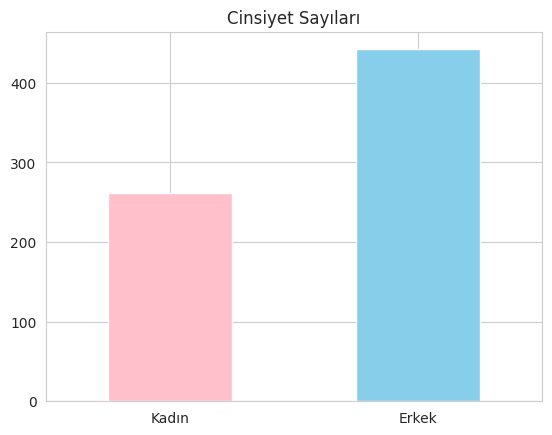

In [15]:
gender_counts = df['gender'].value_counts(dropna=False)[['F', 'M']]
gender_counts.plot(kind='bar', color=['pink', 'skyblue'])
plt.title('Cinsiyet Sayıları')
plt.xlabel('')
plt.ylabel('')
plt.xticks(ticks=[0, 1], labels=['Kadın', 'Erkek'], rotation=0)
plt.show()

## new